In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [ ]:
import yfinance as yf
import pandas as pd

stock = 'NOW'
data = yf.download(
    stock, 
    start='2020-01-01', 
    end='2024-01-01',
    multi_level_index=False,
    progress=False
)

# Reorder to classic OHLCV
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
data = data[[c for c in cols if c in data.columns]]

# Convert Volume to integer
data['Volume'] = data['Volume'].astype('int64')

# === Add Year, Month, Day columns ===
data = data.reset_index()                    # Move Date from index to column
data['Date'] = pd.to_datetime(data['Date'])  # Ensure it's datetime

data['Year']  = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day']   = data['Date'].dt.day
data = data.set_index('Date')

# Optional: Reorder columns nicely
data = data[['Year', 'Month', 'Day', 'Open', 'High', 'Low', 'Close', 'Volume']]

In [24]:
# === Returns ===
data['daily_pct']   = data['Close'].pct_change() * 100                  # close-to-close
data['intraday_pct'] = (data['Close'] - data['Open']) / data['Open'] * 100  # your original

# Weekly & Monthly returns (forward-looking for analysis, or use shift for signals)
data['weekly_pct']  = data['Close'].pct_change(5) * 100     # ~1 trading week
data['monthly_pct'] = data['Close'].pct_change(21) * 100    # ~1 month
data[['Close', 'daily_pct', 'intraday_pct', 'weekly_pct', 'monthly_pct']].tail(10)

,Close,daily_pct,intraday_pct,weekly_pct,monthly_pct
996,139.647995,2.623489,3.403128,-0.120157,7.273009
997,140.744003,0.784836,0.242156,-0.198547,7.886192
998,141.542007,0.566990,0.284829,-1.224038,8.153015
999,138.759995,-1.965503,-1.458662,-3.051822,4.030462
1000,140.151993,1.003170,0.001426,2.993864,4.841413
1001,139.509995,-0.458073,-0.895084,-0.098820,4.164791
1002,140.246002,0.527566,0.151396,-0.353835,4.055500
1003,140.751999,0.360792,0.349350,-0.558144,4.952650
1004,140.492004,-0.184718,-0.591531,1.248206,5.594973
1005,141.298004,0.573698,-0.072129,0.817692,4.059335


In [25]:
# Moving averages as "true" local value
data['sma_20'] = data['Close'].rolling(20).mean()
data['sma_50'] = data['Close'].rolling(50).mean()
data['ema_20'] = data['Close'].ewm(span=20, adjust=False).mean()

# Z-score: how many std devs away from 20-day mean (best local mean-reversion signal)
rolling_std = data['Close'].rolling(20).std()
data['zscore_20'] = (data['Close'] - data['sma_20']) / rolling_std

# Bollinger Bands (classic volatility envelope)
data['bb_upper'] = data['sma_20'] + 2 * rolling_std
data['bb_lower'] = data['sma_20'] - 2 * rolling_std
data['bb_width'] = (data['bb_upper'] - data['bb_lower']) / data['sma_20'] * 100  # % width = volatility
data['bb_pct']   = (data['Close'] - data['bb_lower']) / (data['bb_upper'] - data['bb_lower'])  # 0–1 position

# RSI (14) – oversold < 30, overbought > 70
delta = data['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = -delta.where(delta < 0, 0).rolling(14).mean()
rs = gain / loss
data['rsi'] = 100 - (100 / (1 + rs))

# Average True Range (volatility in $)
high_low = data['High'] - data['Low']
high_close = (data['High'] - data['Close'].shift()).abs()
low_close = (data['Low'] - data['Close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
data['atr_14'] = tr.rolling(14).mean()
data['atr_pct'] = data['atr_14'] / data['Close'] * 100

In [26]:
# Define clear oversold / overbought regimes
data['oversold_z']   = data['zscore_20'] < -1.5          # strong mean reversion candidate
data['overbought_z'] = data['zscore_20'] >  1.5
data['oversold_rsi'] = data['rsi'] < 30
data['overbought_rsi'] = data['rsi'] > 70
data['bb_oversold']  = data['bb_pct'] < 0.05             # near lower band
data['bb_overbought'] = data['bb_pct'] > 0.95

# Forward returns (what happens AFTER the signal)
data['fwd_1d']  = data['Close'].pct_change(1).shift(-1) * 100
data['fwd_5d']  = data['Close'].pct_change(5).shift(-5) * 100
data['fwd_10d'] = data['Close'].pct_change(10).shift(-10) * 100
data['fwd_21d'] = data['Close'].pct_change(21).shift(-21) * 100

# === Probability tables ===
def regime_stats(mask, name):
    subset = data[mask].dropna(subset=['fwd_5d', 'fwd_10d'])
    if len(subset) < 10:
        return f"{name}: too few samples ({len(subset)})"
    
    print(f"\n=== {name} (n={len(subset)}) ===")
    print(f"Avg 5-day return:  {subset['fwd_5d'].mean():.2f}%  (win rate: {(subset['fwd_5d'] > 0).mean()*100:.1f}%)")
    print(f"Avg 10-day return: {subset['fwd_10d'].mean():.2f}%  (win rate: {(subset['fwd_10d'] > 0).mean()*100:.1f}%)")
    print(f"Avg 21-day return: {subset['fwd_21d'].mean():.2f}%  (win rate: {(subset['fwd_21d'] > 0).mean()*100:.1f}%)")
    print(f"Median 5d: {subset['fwd_5d'].median():.2f}% | 10d: {subset['fwd_10d'].median():.2f}%")

# Run the key regimes
regime_stats(data['oversold_z'],   "Z-score < -1.5 (oversold)")
regime_stats(data['overbought_z'], "Z-score > +1.5 (overbought)")
regime_stats(data['oversold_rsi'], "RSI < 30")
regime_stats(data['bb_oversold'],  "Near lower Bollinger Band")

# Combined strong oversold
strong_oversold = data['oversold_z'] & data['oversold_rsi']
regime_stats(strong_oversold, "Strong Oversold (Z < -1.5 AND RSI < 30)")


=== Z-score < -1.5 (oversold) (n=113) ===
Avg 5-day return:  1.11%  (win rate: 57.5%)
Avg 10-day return: 2.32%  (win rate: 60.2%)
Avg 21-day return: 4.70%  (win rate: 62.8%)
Median 5d: 0.58% | 10d: 2.71%

=== Z-score > +1.5 (overbought) (n=183) ===
Avg 5-day return:  0.74%  (win rate: 56.8%)
Avg 10-day return: 1.11%  (win rate: 59.6%)
Avg 21-day return: 0.47%  (win rate: 50.8%)
Median 5d: 0.49% | 10d: 0.93%

=== RSI < 30 (n=68) ===
Avg 5-day return:  2.14%  (win rate: 64.7%)
Avg 10-day return: 1.40%  (win rate: 47.1%)
Avg 21-day return: 3.34%  (win rate: 58.8%)
Median 5d: 2.53% | 10d: -0.34%

=== Near lower Bollinger Band (n=57) ===
Avg 5-day return:  0.75%  (win rate: 56.1%)
Avg 10-day return: 2.33%  (win rate: 64.9%)
Avg 21-day return: 4.38%  (win rate: 61.4%)
Median 5d: 0.15% | 10d: 3.16%

=== Strong Oversold (Z < -1.5 AND RSI < 30) (n=35) ===
Avg 5-day return:  0.36%  (win rate: 54.3%)
Avg 10-day return: 0.90%  (win rate: 45.7%)
Avg 21-day return: 0.78%  (win rate: 42.9%)
Median 5

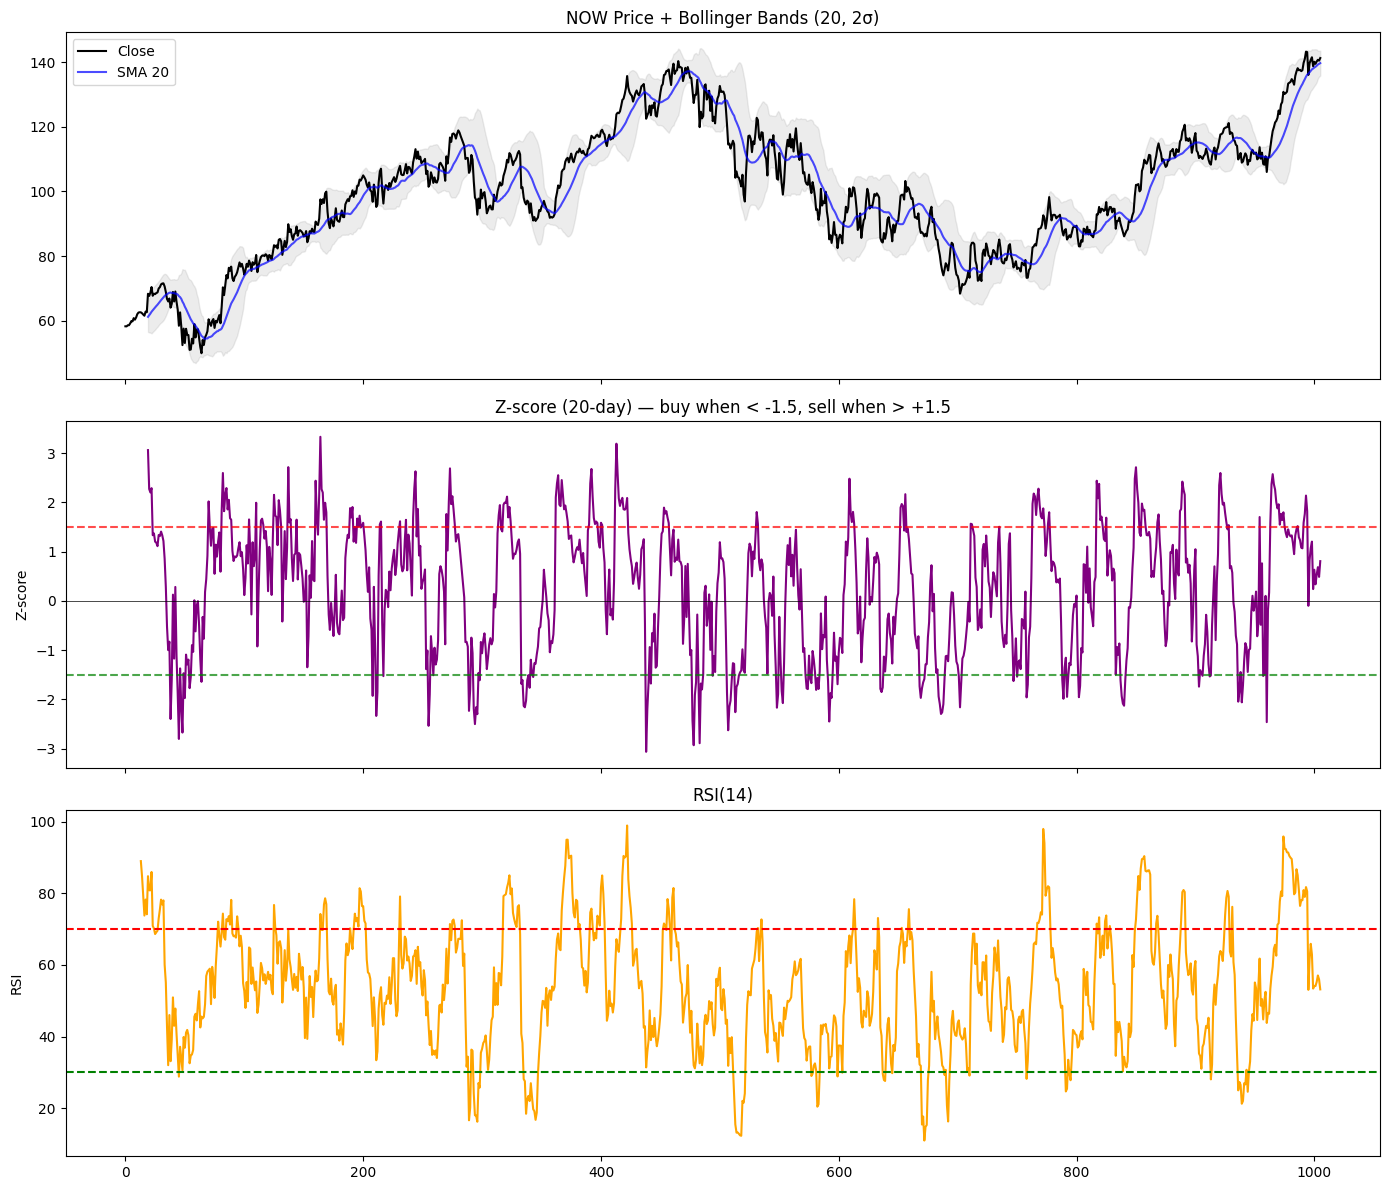

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Price + Bollinger
axes[0].plot(data['Close'], label='Close', color='black', lw=1.5)
axes[0].plot(data['sma_20'], label='SMA 20', color='blue', alpha=0.7)
axes[0].fill_between(data.index, data['bb_lower'], data['bb_upper'], alpha=0.15, color='gray')
axes[0].set_title('NOW Price + Bollinger Bands (20, 2σ)')
axes[0].legend()

# Z-score
axes[1].plot(data['zscore_20'], color='purple')
axes[1].axhline(1.5, color='red', ls='--', alpha=0.7)
axes[1].axhline(-1.5, color='green', ls='--', alpha=0.7)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Z-score (20-day) — buy when < -1.5, sell when > +1.5')
axes[1].set_ylabel('Z-score')

# RSI
axes[2].plot(data['rsi'], color='orange')
axes[2].axhline(70, color='red', ls='--')
axes[2].axhline(30, color='green', ls='--')
axes[2].set_title('RSI(14)')
axes[2].set_ylabel('RSI')

plt.tight_layout()
plt.show()